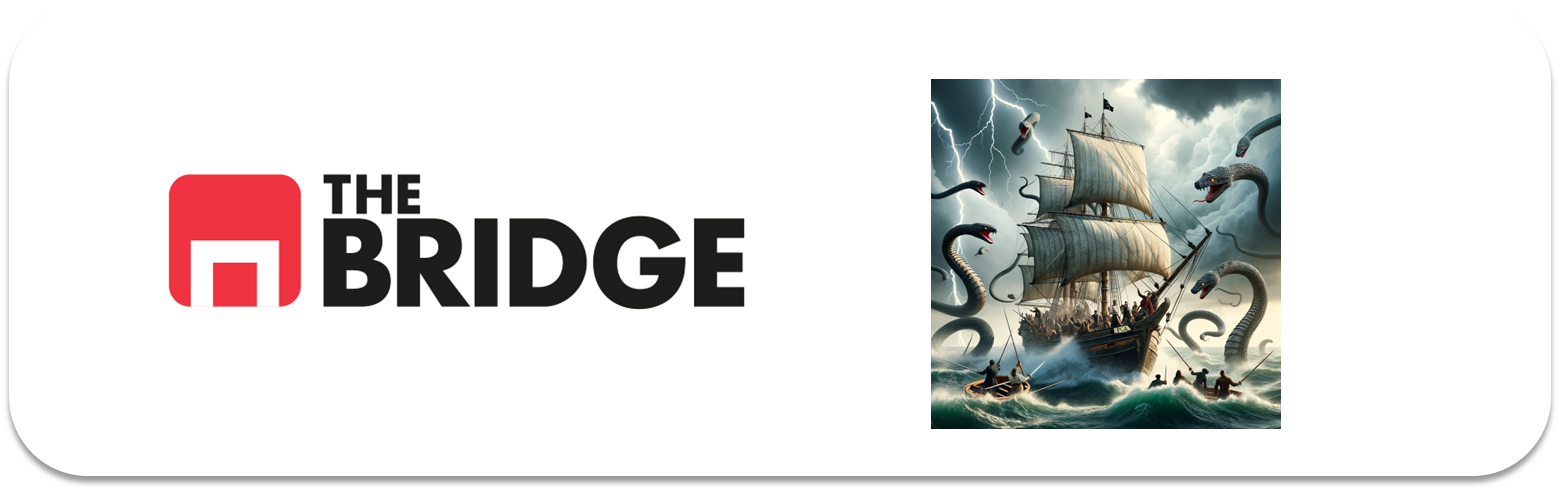

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [56]:
# Tratamiento de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preparación y validación
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler

# Selección de features
from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    mutual_info_classif,
    VarianceThreshold,
    SelectFromModel,
    RFE,
    SequentialFeatureSelector
)

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluación
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

# Reducción de dimensionalidad
from sklearn.decomposition import PCA

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


## 1. Preparación y tratamiento de los datos

Comenzamos cargando el dataset de *credit scoring* y realizando una primera inspección de su estructura, dimensiones, tipos de variables y presencia de valores nulos antes de aplicar cualquier transformación.

### 1.1 Carga del dataset

Cargamos el dataset de *credit scoring* y realizamos una primera visualización para comprobar que los datos se han importado correctamente.

In [57]:
df = pd.read_csv("data/credit_npo.csv")

df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


### 1.2 Inspección inicial del dataset

Revisamos las dimensiones del dataset, los tipos de datos y la cantidad de valores nulos para conocer su estructura antes de realizar el tratamiento de las variables.

In [58]:
print("Dimensiones del dataset:", df.shape)

df.info()

Dimensiones del dataset: (12537, 11)
<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  fl

In [59]:
df.isnull().sum()

SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64

### 1.3 Tratamiento de valores nulos

El dataset presenta valores nulos únicamente en `MonthlyIncome` y `NumberOfDependents`. Siguiendo las indicaciones del ejercicio, eliminamos las filas que contienen valores nulos y comprobamos las dimensiones resultantes.

In [60]:
df = df.dropna().copy()

print("Dimensiones después de eliminar nulos:", df.shape)
print("\nValores nulos restantes:")
print(df.isnull().sum())

Dimensiones después de eliminar nulos: (11816, 11)

Valores nulos restantes:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


### 1.4 Análisis de las variables `NumberOf...`

Antes de transformar variables numéricas en categóricas, analizamos la distribución de las features relacionadas con cantidades o número de eventos para determinar cuáles pueden representarse de forma adecuada mediante 2 o 3 categorías.

In [61]:
columnas_number = [
    col for col in df.columns
    if col.startswith("Number")
]

columnas_number

['NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

#### 1.4.1 Distribución de las variables `NumberOf...`

Analizamos los valores y frecuencias de las variables `NumberOf...` para identificar cuáles pueden agruparse de forma razonable en un máximo de 2 o 3 categorías.

In [62]:
for col in columnas_number:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().sort_index())


--- NumberOfTime30-59DaysPastDueNotWorse ---
NumberOfTime30-59DaysPastDueNotWorse
0     9818
1     1354
2      397
3      127
4       64
5       23
6       20
7        1
8        2
98      10
Name: count, dtype: int64

--- NumberOfOpenCreditLinesAndLoans ---
NumberOfOpenCreditLinesAndLoans
0      112
1      307
2      445
3      638
4      848
5      963
6     1031
7     1110
8     1009
9      965
10     765
11     719
12     574
13     454
14     365
15     338
16     236
17     216
18     151
19     129
20     118
21      62
22      61
23      39
24      38
25      30
26      19
27      16
28      13
29      10
30      10
31       7
32       3
33       4
34       2
35       2
36       1
38       1
40       1
41       1
43       1
48       1
49       1
Name: count, dtype: int64

--- NumberOfTimes90DaysLate ---
NumberOfTimes90DaysLate
0     11156
1       394
2       142
3        54
4        31
5        14
6         6
7         3
8         3
9         1
10        1
13        1
98      

### 1.5 Separación en conjuntos de entrenamiento y test

Separamos el dataset en un conjunto de entrenamiento y otro de test. El conjunto de entrenamiento se utilizará para realizar el análisis y la selección de features, mientras que el conjunto de test se reservará para la evaluación final del modelo.

In [63]:
train_set, test_set = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["SeriousDlqin2yrs"]
)

print("Dimensiones Train:", train_set.shape)
print("Dimensiones Test:", test_set.shape)

Dimensiones Train: (9452, 11)
Dimensiones Test: (2364, 11)


#### 1.5.1 Comprobación de la distribución de la variable objetivo

Comprobamos que la proporción de las clases de `SeriousDlqin2yrs` se mantiene similar en los conjuntos de entrenamiento y test después de realizar la división estratificada.

In [64]:
print("Distribución en Train:")
print(
    train_set["SeriousDlqin2yrs"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nDistribución en Test:")
print(
    test_set["SeriousDlqin2yrs"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Distribución en Train:
SeriousDlqin2yrs
0    92.98
1     7.02
Name: proportion, dtype: float64

Distribución en Test:
SeriousDlqin2yrs
0    92.98
1     7.02
Name: proportion, dtype: float64


### 1.6 Categorización de las variables de mora

A partir de la distribución observada, transformamos las variables relacionadas con retrasos en variables categóricas con un máximo de tres niveles.

- `NumberOfTime30-59DaysPastDueNotWorse`: 0 retrasos, 1 retraso y 2 o más retrasos.
- `NumberOfTimes90DaysLate`: 0 retrasos y 1 o más retrasos.
- `NumberOfTime60-89DaysPastDueNotWorse`: 0 retrasos y 1 o más retrasos.

Las transformaciones se aplican tanto al conjunto de entrenamiento como al conjunto de test.

In [65]:
for dataset in [train_set, test_set]:
    
    dataset["NumberOfTime30-59DaysPastDueNotWorse"] = pd.cut(
        dataset["NumberOfTime30-59DaysPastDueNotWorse"],
        bins=[-1, 0, 1, np.inf],
        labels=["0", "1", "2+"]
    )

    dataset["NumberOfTimes90DaysLate"] = pd.cut(
        dataset["NumberOfTimes90DaysLate"],
        bins=[-1, 0, np.inf],
        labels=["0", "1+"]
    )

    dataset["NumberOfTime60-89DaysPastDueNotWorse"] = pd.cut(
        dataset["NumberOfTime60-89DaysPastDueNotWorse"],
        bins=[-1, 0, np.inf],
        labels=["0", "1+"]
    )

#### 1.6.1 Comprobación de las categorías creadas

Comprobamos la distribución de las nuevas categorías en el conjunto de entrenamiento para verificar que la transformación se ha realizado correctamente y que no se han generado valores nulos.

In [66]:
cols_mora = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse"
]

for col in cols_mora:
    print(f"\n--- {col} ---")
    print(train_set[col].value_counts(dropna=False))


--- NumberOfTime30-59DaysPastDueNotWorse ---
NumberOfTime30-59DaysPastDueNotWorse
0     7840
1     1086
2+     526
Name: count, dtype: int64

--- NumberOfTimes90DaysLate ---
NumberOfTimes90DaysLate
0     8932
1+     520
Name: count, dtype: int64

--- NumberOfTime60-89DaysPastDueNotWorse ---
NumberOfTime60-89DaysPastDueNotWorse
0     8967
1+     485
Name: count, dtype: int64


#### 1.6.2 Análisis de `NumberRealEstateLoansOrLines`

Analizamos la distribución de `NumberRealEstateLoansOrLines` en el conjunto de entrenamiento para determinar si resulta conveniente mantenerla como variable numérica o agrupar sus valores en categorías.

In [67]:
train_set["NumberRealEstateLoansOrLines"].value_counts(
    normalize=True
).sort_index().mul(100).round(2)

NumberRealEstateLoansOrLines
0     35.56
1     35.21
2     22.05
3      4.34
4      1.58
5      0.69
6      0.23
7      0.12
8      0.07
9      0.03
10     0.02
11     0.04
12     0.02
13     0.01
16     0.02
19     0.01
Name: proportion, dtype: float64

### 1.7 Comprobación final de los tipos de variables

Comprobamos los tipos de datos después de las transformaciones realizadas para identificar las variables numéricas y categóricas que utilizaremos posteriormente en las distintas técnicas de selección de features.

In [68]:
train_set.dtypes


SeriousDlqin2yrs                           int64
RevolvingUtilizationOfUnsecuredLines     float64
age                                        int64
NumberOfTime30-59DaysPastDueNotWorse    category
DebtRatio                                float64
MonthlyIncome                            float64
NumberOfOpenCreditLinesAndLoans            int64
NumberOfTimes90DaysLate                 category
NumberRealEstateLoansOrLines               int64
NumberOfTime60-89DaysPastDueNotWorse    category
NumberOfDependents                       float64
dtype: object

## 2. MiniEDA y selección de features

A partir del conjunto de entrenamiento aplicaremos diferentes técnicas de selección de características con el objetivo de identificar las variables con mayor capacidad predictiva sobre `SeriousDlqin2yrs`.

Se utilizarán métodos de filtrado, métodos estadísticos y métodos basados en modelos, para posteriormente comparar los conjuntos de variables obtenidos.

### 2.1 Preparación de variables para el análisis visual

Siguiendo la clasificación realizada durante el MiniEDA, separamos las variables en numéricas y categóricas. `NumberRealEstateLoansOrLines` se mantiene como variable numérica discreta debido a que presenta suficientes valores con representación y no resulta necesario reducirla a categorías.

In [69]:
# Variables numéricas
features_num = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfDependents",
    "NumberRealEstateLoansOrLines"
]

# Variables categóricas
features_cat = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse"
]

print("Variables numéricas:", len(features_num))
print("Variables categóricas:", len(features_cat))

Variables numéricas: 7
Variables categóricas: 3


#### 2.1.1 Análisis visual de las variables categóricas

Analizamos visualmente la relación entre las variables categóricas y la variable objetivo `SeriousDlqin2yrs`. Para cada categoría observamos la proporción de clientes que presentan dificultades graves de pago, lo que permite identificar posibles diferencias en el comportamiento de la variable objetivo.

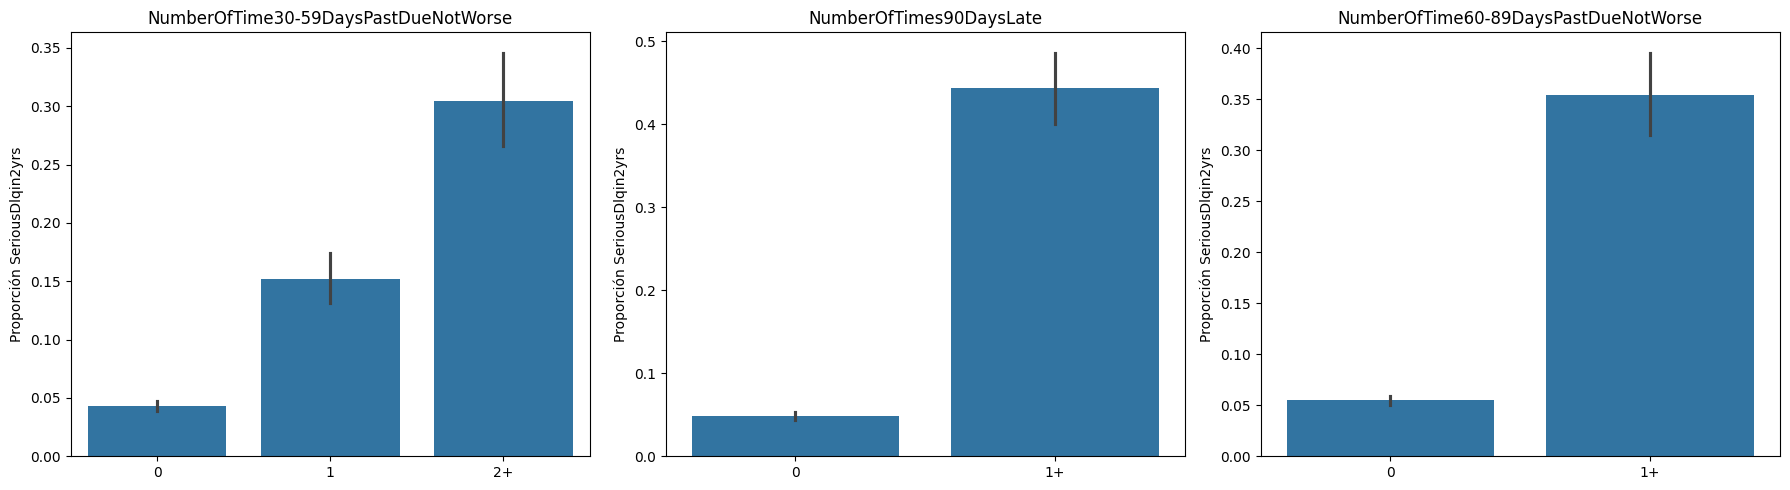

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, features_cat):
    
    sns.barplot(
        data=train_set,
        x=col,
        y="SeriousDlqin2yrs",
        ax=ax
    )
    
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Proporción SeriousDlqin2yrs")

plt.tight_layout()
plt.show()

**Conclusión:** Las tres variables categóricas muestran diferencias claras en la proporción de `SeriousDlqin2yrs` entre sus categorías. En todos los casos, la presencia de retrasos en los pagos está asociada con una mayor proporción de la clase positiva. Por tanto, inicialmente se consideran variables potencialmente relevantes para la predicción.

#### 2.1.2 Análisis visual de las variables numéricas

Analizamos la distribución de las variables numéricas en función de la variable objetivo `SeriousDlqin2yrs`, con el fin de identificar visualmente aquellas que presentan diferencias entre las dos clases.

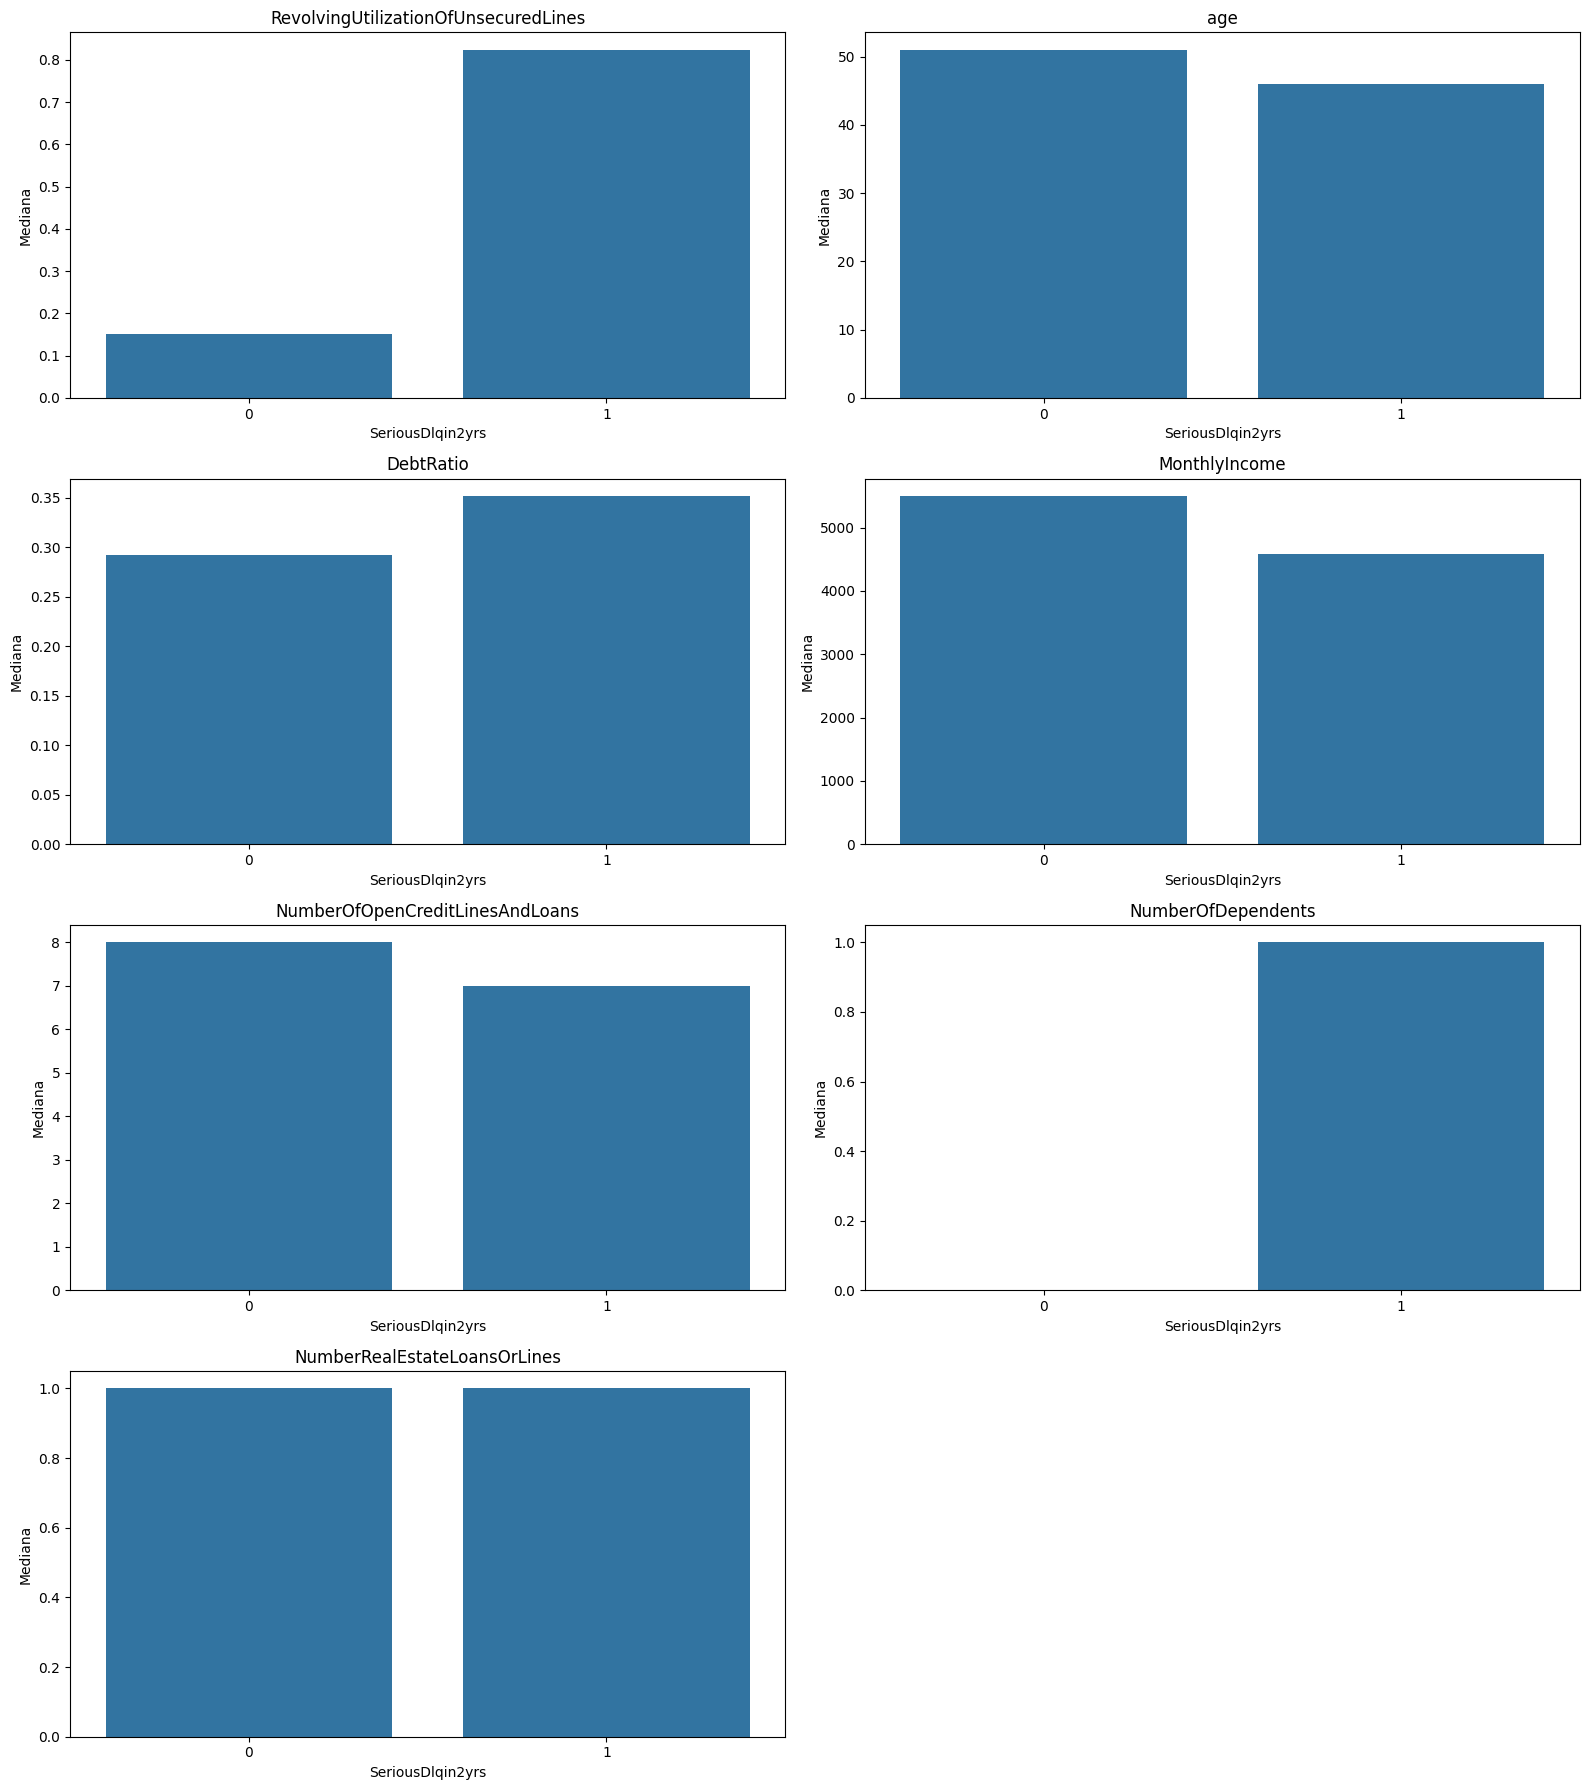

In [71]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for ax, col in zip(axes, features_num):

    medianas = (
        train_set
        .groupby("SeriousDlqin2yrs")[col]
        .median()
        .reset_index()
    )

    sns.barplot(
        data=medianas,
        x="SeriousDlqin2yrs",
        y=col,
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel("SeriousDlqin2yrs")
    ax.set_ylabel("Mediana")

for ax in axes[len(features_num):]:
    ax.remove()

plt.tight_layout()
plt.show()

**Conclusión:** La comparación de medianas muestra diferencias entre las clases especialmente en `RevolvingUtilizationOfUnsecuredLines`, que presenta valores considerablemente mayores en la clase positiva. También se observan diferencias en `age`, `MonthlyIncome` y `NumberOfDependents`. Por el contrario, `NumberRealEstateLoansOrLines` presenta medianas prácticamente iguales entre ambas clases.

Este análisis visual constituye una primera aproximación, por lo que se complementará con el análisis de correlación y el filtrado mediante umbral de varianza antes de realizar la selección de variables.

#### 2.1.3 Correlación de las variables numéricas con la variable objetivo

Calculamos la correlación de las variables numéricas con `SeriousDlqin2yrs` para cuantificar la intensidad y dirección de su relación lineal con la variable objetivo. Este análisis complementa la información obtenida mediante la exploración visual.

In [72]:
correlaciones = (
    train_set[features_num + ["SeriousDlqin2yrs"]]
    .corr()["SeriousDlqin2yrs"]
    .drop("SeriousDlqin2yrs")
    .sort_values(key=abs, ascending=False)
)

correlaciones.round(4)

RevolvingUtilizationOfUnsecuredLines    0.2775
age                                    -0.1053
NumberOfDependents                      0.0461
NumberOfOpenCreditLinesAndLoans        -0.0335
MonthlyIncome                          -0.0254
NumberRealEstateLoansOrLines            0.0058
DebtRatio                               0.0001
Name: SeriousDlqin2yrs, dtype: float64

**Conclusión:** `RevolvingUtilizationOfUnsecuredLines` presenta la mayor correlación con la variable objetivo (0.2775), seguida de `age` (-0.1053). El resto de variables numéricas muestran correlaciones lineales considerablemente menores, destacando `DebtRatio` y `NumberRealEstateLoansOrLines` con valores próximos a cero.

Estos resultados se combinarán con el análisis visual y el filtrado mediante umbral de varianza antes de realizar la primera selección de features.

### 2.1.4 Selección de features a partir del análisis visual

A partir del análisis visual realizado, seleccionamos las variables que muestran una posible relación con la variable objetivo. Esta primera selección se utilizará como punto de partida para aplicar posteriormente el filtrado mediante umbral de varianza.

In [73]:
features_visual = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "MonthlyIncome",
    "DebtRatio",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse"
]

features_visual

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'MonthlyIncome',
 'DebtRatio',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfTimes90DaysLate',
 'NumberOfTime60-89DaysPastDueNotWorse']

### 2.1.5 Filtrado mediante umbral de varianza

Aplicamos `VarianceThreshold` para analizar la variabilidad de las features seleccionadas visualmente. Probamos diferentes valores de umbral con el objetivo de observar qué variables se mantienen a medida que aumenta la varianza mínima exigida.

In [74]:
features_visual_continuas = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "MonthlyIncome",
    "DebtRatio"
]

for umbral_varianza in np.arange(0, 1, 0.1):
    print(f"Para umbral = {umbral_varianza:.1f}")
    
    var_selector = VarianceThreshold(umbral_varianza)
    var_selector.fit(train_set[features_visual_continuas])
    
    print(
        "Variables seleccionadas:",
        var_selector.get_feature_names_out()
    )
    print()

Para umbral = 0.0
Variables seleccionadas: ['RevolvingUtilizationOfUnsecuredLines' 'age' 'MonthlyIncome' 'DebtRatio']

Para umbral = 0.1
Variables seleccionadas: ['RevolvingUtilizationOfUnsecuredLines' 'age' 'MonthlyIncome' 'DebtRatio']

Para umbral = 0.2
Variables seleccionadas: ['age' 'MonthlyIncome' 'DebtRatio']

Para umbral = 0.3
Variables seleccionadas: ['age' 'MonthlyIncome' 'DebtRatio']

Para umbral = 0.4
Variables seleccionadas: ['age' 'MonthlyIncome' 'DebtRatio']

Para umbral = 0.5
Variables seleccionadas: ['age' 'MonthlyIncome' 'DebtRatio']

Para umbral = 0.6
Variables seleccionadas: ['age' 'MonthlyIncome' 'DebtRatio']

Para umbral = 0.7
Variables seleccionadas: ['age' 'MonthlyIncome' 'DebtRatio']

Para umbral = 0.8
Variables seleccionadas: ['age' 'MonthlyIncome' 'DebtRatio']

Para umbral = 0.9
Variables seleccionadas: ['age' 'MonthlyIncome' 'DebtRatio']



**Conclusión:** Al aumentar el umbral de varianza hasta 0.2, `RevolvingUtilizationOfUnsecuredLines` deja de ser seleccionada, mientras que `age`, `MonthlyIncome` y `DebtRatio` se mantienen. Sin embargo, este método únicamente analiza la variabilidad de cada feature y no su relación con la variable objetivo. Dado que `RevolvingUtilizationOfUnsecuredLines` mostró la mayor correlación con `SeriousDlqin2yrs`, no se descarta de la selección.

Las variables categóricas de mora tampoco se someten a este filtro, ya que su baja varianza puede deberse al reducido número de categorías y al desbalance entre ellas.

### 2.2 Selección estadística de features

En este segundo método aplicamos técnicas estadísticas de selección de características. Para las variables numéricas utilizamos `SelectKBest` junto con ANOVA (`f_classif`), mientras que las variables categóricas se analizarán mediante información mutua (`mutual_info_classif`).

#### 2.2.1 Selección de variables numéricas mediante ANOVA

Aplicamos `SelectKBest` con `f_classif` para evaluar la relación entre cada variable numérica y la variable objetivo. En esta primera fase analizamos las puntuaciones obtenidas por todas las variables antes de decidir cuáles formarán parte de la selección.

In [75]:
X_num = train_set[features_num]
y_train = train_set["SeriousDlqin2yrs"]

selector_anova = SelectKBest(
    score_func=f_classif,
    k="all"
)

selector_anova.fit(X_num, y_train)

resultados_anova = pd.DataFrame({
    "Feature": features_num,
    "ANOVA_score": selector_anova.scores_,
    "p_value": selector_anova.pvalues_
}).sort_values("ANOVA_score", ascending=False)

resultados_anova.round(4)

,Feature,ANOVA_score,p_value
0,RevolvingUtilizationOfUnsecuredLines,788.2699,0.0000
1,age,105.8574,0.0000
5,NumberOfDependents,20.1253,0.0000
4,NumberOfOpenCreditLinesAndLoans,10.6262,0.0011
3,MonthlyIncome,6.1243,0.0134
6,NumberRealEstateLoansOrLines,0.3147,0.5748
2,DebtRatio,0.0001,0.9931


**Conclusión:** El análisis ANOVA muestra que `RevolvingUtilizationOfUnsecuredLines` presenta la relación más fuerte con la variable objetivo, seguida de `age` y `NumberOfDependents`. Las cinco primeras variables presentan valores de `p_value` inferiores a 0.05, mientras que `NumberRealEstateLoansOrLines` y `DebtRatio` no muestran una relación estadísticamente significativa mediante este método.

#### 2.2.2 Selección de variables categóricas mediante Mutual Information

Para evaluar la relación entre las variables categóricas y la variable objetivo utilizamos `mutual_info_classif`. Previamente convertimos las categorías a códigos numéricos para poder aplicar el método, manteniendo estas variables identificadas como discretas.

In [76]:
X_cat = train_set[features_cat].copy()

for col in features_cat:
    X_cat[col] = X_cat[col].cat.codes

mi_scores = mutual_info_classif(
    X_cat,
    y_train,
    discrete_features=True,
    random_state=42
)

resultados_mi = pd.DataFrame({
    "Feature": features_cat,
    "Mutual_Information": mi_scores
}).sort_values("Mutual_Information", ascending=False)

resultados_mi.round(4)

,Feature,Mutual_Information
1,NumberOfTimes90DaysLate,0.0332
0,NumberOfTime30-59DaysPastDueNotWorse,0.0234
2,NumberOfTime60-89DaysPastDueNotWorse,0.0192


**Conclusión:** Las tres variables categóricas presentan información mutua con la variable objetivo. `NumberOfTimes90DaysLate` obtiene la puntuación más alta, seguida de `NumberOfTime30-59DaysPastDueNotWorse` y `NumberOfTime60-89DaysPastDueNotWorse`, por lo que las tres se consideran potencialmente relevantes para la selección de features.

#### 2.2.3 Primera selección mediante ANOVA y Mutual Information

A partir de los resultados obtenidos, seleccionamos las tres variables numéricas con mayor puntuación ANOVA y las tres variables categóricas evaluadas mediante Mutual Information. De esta forma obtenemos una primera división de seis features, respetando el máximo indicado en el ejercicio.

In [77]:
features_kbest_mi = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfDependents",
    "NumberOfTimes90DaysLate",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse"
]

print("Número de features seleccionadas:", len(features_kbest_mi))
features_kbest_mi

Número de features seleccionadas: 6


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfDependents',
 'NumberOfTimes90DaysLate',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfTime60-89DaysPastDueNotWorse']

### 2.3 Selección de features mediante `SelectFromModel`

En este tercer método utilizamos un modelo intermedio para seleccionar las características más relevantes. Siguiendo este enfoque, empleamos un `RandomForestClassifier` con `class_weight="balanced"` debido al desbalance existente en la variable objetivo.

La selección se realizará mediante `SelectFromModel`, utilizando como umbral la mediana de las importancias obtenidas por el modelo.

In [78]:
features = features_num + features_cat

# Copia de las features para el modelo
X_modelo = train_set[features].copy()

# Convertimos las variables categóricas a códigos numéricos
for col in features_cat:
    X_modelo[col] = X_modelo[col].cat.codes

rf_selector = RandomForestClassifier(
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

selector_modelo = SelectFromModel(
    estimator=rf_selector,
    threshold="median"
)

selector_modelo.fit(
    X_modelo,
    train_set["SeriousDlqin2yrs"]
)

features_modelo = list(selector_modelo.get_feature_names_out())

features_modelo

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'DebtRatio',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfTimes90DaysLate']

**Conclusión:** `SelectFromModel`, utilizando un `RandomForestClassifier` como modelo intermedio y la mediana de las importancias como umbral, selecciona cinco variables: `RevolvingUtilizationOfUnsecuredLines`, `age`, `DebtRatio`, `NumberOfTime30-59DaysPastDueNotWorse` y `NumberOfTimes90DaysLate`.

Esta selección combina variables numéricas y variables relacionadas con los retrasos en los pagos, obteniendo un conjunto reducido de cinco features que utilizaremos posteriormente para comparar su capacidad predictiva frente a los demás métodos de selección.

### 2.4 Selección de features mediante RFE

Aplicamos `RFE` (*Recursive Feature Elimination*) para seleccionar las características más relevantes de forma recursiva. Este método entrena un modelo, elimina progresivamente las variables menos importantes y repite el proceso hasta alcanzar el número de features indicado.

En este caso buscamos obtener una primera selección de un máximo de seis variables para posteriormente compararla con los resultados obtenidos mediante los demás métodos de selección.

#### 2.4.1 Escalado de las variables para RFE

Antes de aplicar RFE con `LogisticRegression`, estandarizamos las variables para evitar que las diferencias de escala afecten al proceso de entrenamiento y dificulten la convergencia del modelo.

El escalado se realiza únicamente sobre una copia de las variables utilizadas por RFE, manteniendo intacto el conjunto de entrenamiento original.

In [79]:
scaler_rfe = StandardScaler()

X_rfe = pd.DataFrame(
    scaler_rfe.fit_transform(X_modelo),
    columns=X_modelo.columns,
    index=X_modelo.index
)

#### 2.4.2 Aplicación de RFE

Una vez estandarizadas las variables, aplicamos `RFE` utilizando `LogisticRegression` como estimador. El proceso eliminará recursivamente las características menos relevantes hasta obtener una selección final de seis features.

In [80]:
rfe = RFE(
    estimator=LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    n_features_to_select=6
)

rfe.fit(
    X_rfe,
    train_set["SeriousDlqin2yrs"]
)

features_rfe = list(X_rfe.columns[rfe.support_])

print("Número de features seleccionadas:", len(features_rfe))
features_rfe

Número de features seleccionadas: 6


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfTimes90DaysLate',
 'NumberOfTime60-89DaysPastDueNotWorse']

**Conclusión:** Tras estandarizar las variables y aplicar RFE con `LogisticRegression`, se seleccionan seis features: `RevolvingUtilizationOfUnsecuredLines`, `age`, `NumberRealEstateLoansOrLines`, `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate` y `NumberOfTime60-89DaysPastDueNotWorse`.

La selección vuelve a destacar `RevolvingUtilizationOfUnsecuredLines` y las tres variables relacionadas con retrasos en los pagos, que también han mostrado relevancia mediante otros métodos de selección.

### 2.5 Selección de features mediante SFS

Aplicamos `SequentialFeatureSelector` (SFS) como último método individual de selección de características. Este método selecciona progresivamente las variables que permiten obtener un mejor rendimiento del modelo según una métrica determinada.

Utilizaremos `LogisticRegression` como estimador y buscaremos un conjunto final de seis features para poder compararlo posteriormente con las selecciones obtenidas mediante los métodos anteriores.

In [81]:
sfs = SequentialFeatureSelector(
    estimator=LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    n_features_to_select=6,
    direction="forward",
    scoring="recall",
    cv=5
)

sfs.fit(
    X_rfe,
    train_set["SeriousDlqin2yrs"]
)

features_sfs = list(X_rfe.columns[sfs.get_support()])

print("Número de features seleccionadas:", len(features_sfs))
features_sfs

Número de features seleccionadas: 6


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfTime60-89DaysPastDueNotWorse']

**Conclusión:** Mediante `SequentialFeatureSelector` (SFS), utilizando `LogisticRegression`, selección hacia delante y `recall` como métrica de evaluación, se obtiene un conjunto de seis features: `RevolvingUtilizationOfUnsecuredLines`, `age`, `NumberOfOpenCreditLinesAndLoans`, `NumberRealEstateLoansOrLines`, `NumberOfTime30-59DaysPastDueNotWorse` y `NumberOfTime60-89DaysPastDueNotWorse`.

Al igual que en métodos anteriores, vuelven a aparecer `RevolvingUtilizationOfUnsecuredLines`, `age` y varias variables relacionadas con los retrasos en los pagos, mostrando consistencia entre diferentes técnicas de selección.

### 2.6 Selección final de features mediante Hard Voting

Combinamos las selecciones obtenidas mediante los cinco métodos anteriores para identificar las variables que presentan un mayor consenso entre las distintas técnicas.

Cada vez que una feature aparece en una de las selecciones recibe un voto. Posteriormente, ordenaremos las variables según el número total de votos obtenidos para construir una selección final de características.

In [82]:
from collections import Counter

listas_seleccion = [
    features_visual,
    features_kbest_mi,
    features_modelo,
    features_rfe,
    features_sfs
]

votos = Counter()

for lista in listas_seleccion:
    votos.update(lista)

votos_features = pd.DataFrame(
    votos.items(),
    columns=["Feature", "Votos"]
).sort_values(
    by="Votos",
    ascending=False
).reset_index(drop=True)

votos_features

,Feature,Votos
0,RevolvingUtilizationOfUnsecuredLines,5
1,age,5
2,NumberOfTime30-59DaysPastDueNotWorse,5
3,NumberOfTimes90DaysLate,4
4,NumberOfTime60-89DaysPastDueNotWorse,4
5,DebtRatio,2
6,NumberRealEstateLoansOrLines,2
7,MonthlyIncome,1
8,NumberOfDependents,1
9,NumberOfOpenCreditLinesAndLoans,1


#### 2.6.1 Visualización de los votos obtenidos

Representamos gráficamente el número de métodos que seleccionaron cada feature. La línea discontinua indica el umbral mínimo de cuatro votos utilizado para construir la selección final mediante Hard Voting.

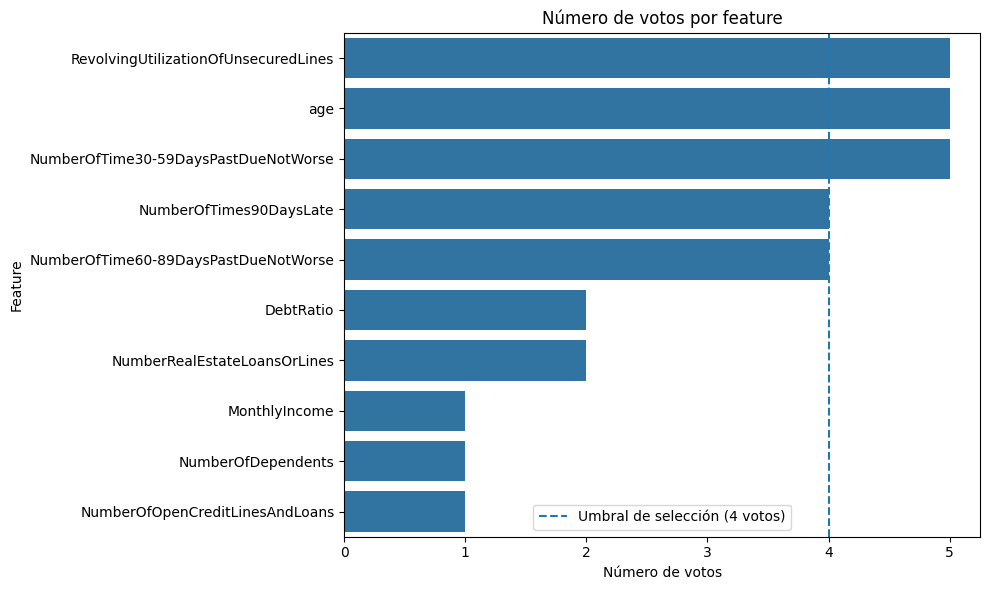

In [83]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=votos_features,
    x="Votos",
    y="Feature"
)

plt.axvline(
    x=4,
    linestyle="--",
    label="Umbral de selección (4 votos)"
)

plt.title("Número de votos por feature")
plt.xlabel("Número de votos")
plt.ylabel("Feature")
plt.legend()

plt.tight_layout()
plt.show()

#### 2.6.2 Selección de features mediante consenso

A partir del conteo de votos, seleccionamos las variables que han sido elegidas por al menos cuatro de los cinco métodos aplicados. De esta forma conservamos las features con mayor consenso entre las diferentes técnicas de selección.

In [84]:
features_voting = (
    votos_features.loc[
        votos_features["Votos"] >= 4,
        "Feature"
    ]
    .tolist()
)

print("Número de features seleccionadas:", len(features_voting))
features_voting

Número de features seleccionadas: 5


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfTimes90DaysLate',
 'NumberOfTime60-89DaysPastDueNotWorse']

**Conclusión:** El Hard Voting muestra un consenso elevado entre los diferentes métodos de selección. `RevolvingUtilizationOfUnsecuredLines`, `age` y `NumberOfTime30-59DaysPastDueNotWorse` fueron seleccionadas por los cinco métodos, mientras que `NumberOfTimes90DaysLate` y `NumberOfTime60-89DaysPastDueNotWorse` aparecieron en cuatro de ellos.

Aplicando como criterio un mínimo de cuatro votos, obtenemos una selección final de cinco features. Este conjunto representa las variables con mayor consenso entre las distintas técnicas de selección utilizadas.

## 3. Comparación de modelos y métodos de selección

Una vez obtenidos los seis conjuntos de features, comparamos su capacidad predictiva utilizando tres modelos de clasificación.

Cada modelo será evaluado mediante validación cruzada sobre cada una de las seis selecciones de características, obteniendo un total de 18 resultados (6 selecciones × 3 modelos).

Debido al desbalance existente en la variable objetivo `SeriousDlqin2yrs`, utilizaremos `balanced_accuracy` como métrica principal de comparación. Esta métrica tiene en cuenta el rendimiento del modelo sobre ambas clases y evita que la clase mayoritaria domine la evaluación.

### 3.1 Modelos utilizados

Definimos los tres modelos de clasificación que utilizaremos para comparar los diferentes conjuntos de features: `RandomForestClassifier`, `XGBClassifier` y `LGBMClassifier`.

La comparación se realizará utilizando `balanced_accuracy` como métrica principal, debido al desbalance existente en la variable objetivo y a la necesidad de evaluar de forma equilibrada el rendimiento sobre ambas clases.

In [85]:
modelos = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}

modelos

{'Random Forest': RandomForestClassifier(random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, ...),
 'LightGBM': LGBMClassifier(random_state=42, verbose=-1)}

### 3.2 Conjuntos de features a comparar

Agrupamos las seis selecciones de características obtenidas mediante los diferentes métodos para poder evaluarlas posteriormente con cada uno de los tres modelos de clasificación.

In [86]:
selecciones_features = {
    "Visual + Varianza": features_visual,
    "ANOVA + MI": features_kbest_mi,
    "SelectFromModel": features_modelo,
    "RFE": features_rfe,
    "SFS": features_sfs,
    "Hard Voting": features_voting
}

for nombre, features in selecciones_features.items():
    print(f"{nombre}: {len(features)} features")
    print(features)
    print()

Visual + Varianza: 7 features
['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'DebtRatio', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']

ANOVA + MI: 6 features
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfDependents', 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse']

SelectFromModel: 5 features
['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate']

RFE: 6 features
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberRealEstateLoansOrLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']

SFS: 6 features
['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse']

Hard Votin

### 3.3 Preparación de los datos para la comparación

Para evaluar los diferentes modelos utilizamos la versión numérica del conjunto de entrenamiento creada anteriormente (`X_modelo`), en la que las variables categóricas de mora fueron transformadas a códigos numéricos.

De esta forma, todos los modelos podrán trabajar con las mismas representaciones de las features y mantendremos intacto el conjunto de entrenamiento original.

In [87]:
X_modelo[features_cat].head()

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse
2031,0,0,0
10352,0,0,0
497,0,0,0
10341,0,0,0
4043,0,0,0


### 3.4 Comparación mediante validación cruzada

Evaluamos cada uno de los tres modelos utilizando los seis conjuntos de features obtenidos anteriormente. Para cada combinación aplicamos validación cruzada con 5 particiones.

Utilizamos `balanced_accuracy` como métrica de evaluación, ya que la variable objetivo presenta un fuerte desbalance entre sus clases. Esta métrica tiene en cuenta el rendimiento del modelo sobre ambas clases y evita que la clase mayoritaria domine la evaluación.

In [88]:
resultados = []

for nombre_seleccion, features in selecciones_features.items():
    
    X = X_modelo[features]
    
    for nombre_modelo, modelo in modelos.items():
        
        scores = cross_val_score(
            modelo,
            X,
            y_train,
            cv=5,
            scoring="balanced_accuracy"
        )
        
        resultados.append({
            "Selección": nombre_seleccion,
            "Modelo": nombre_modelo,
            "Balanced Accuracy": scores.mean()
        })

resultados_cv = pd.DataFrame(resultados)

resultados_cv

,Selección,Modelo,Balanced Accuracy
0,Visual + Varianza,Random Forest,0.587470
1,Visual + Varianza,XGBoost,0.599177
2,Visual + Varianza,LightGBM,0.594790
3,ANOVA + MI,Random Forest,0.581786
4,ANOVA + MI,XGBoost,0.586060
5,ANOVA + MI,LightGBM,0.579320
6,SelectFromModel,Random Forest,0.587153
7,SelectFromModel,XGBoost,0.594729
8,SelectFromModel,LightGBM,0.587630
9,RFE,Random Forest,0.594982


#### 3.4.1 Comparación visual de los resultados

Representamos gráficamente los resultados obtenidos mediante validación cruzada para comparar el rendimiento de los tres modelos sobre cada uno de los seis conjuntos de features.

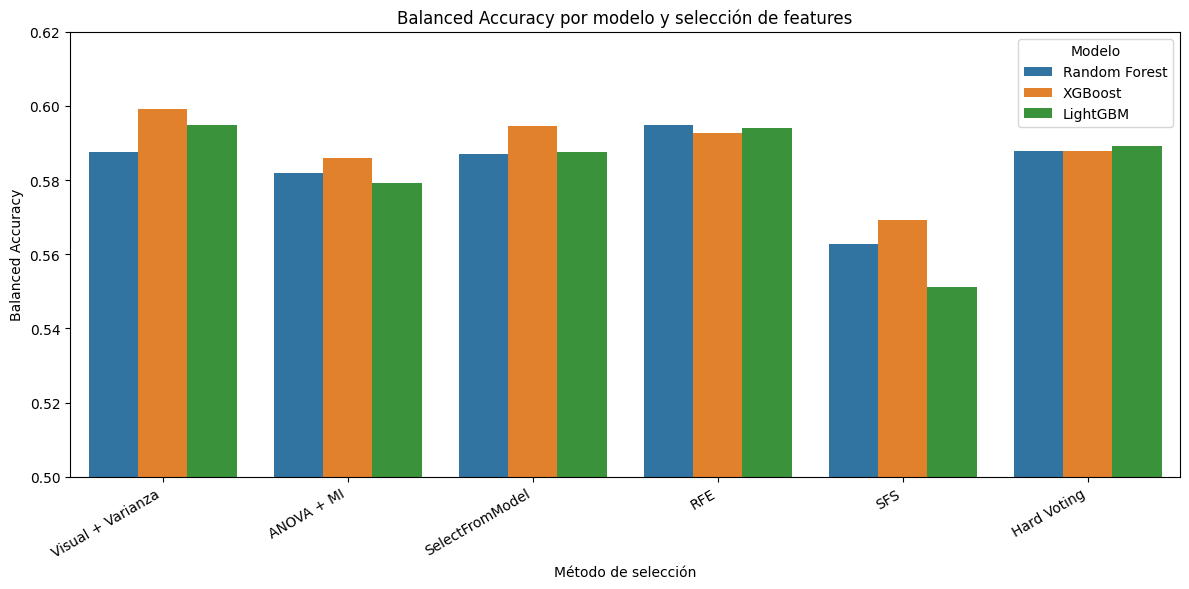

In [89]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=resultados_cv,
    x="Selección",
    y="Balanced Accuracy",
    hue="Modelo"
)

plt.title("Balanced Accuracy por modelo y selección de features")
plt.xlabel("Método de selección")
plt.ylabel("Balanced Accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.5, 0.62)
plt.legend(title="Modelo")

plt.tight_layout()
plt.show()

**Conclusión:** La comparación mediante validación cruzada muestra resultados relativamente próximos entre varias de las combinaciones evaluadas. Sin embargo, la selección `Visual + Varianza` junto con `XGBoost` obtiene el mayor `Balanced Accuracy`, con un valor aproximado de 0.5992.

También se observa que RFE presenta un comportamiento bastante estable con los tres modelos, mientras que SFS obtiene los valores más bajos de la comparación.

Por tanto, para continuar con la optimización de hiperparámetros seleccionamos `XGBoost` como modelo y el conjunto de features obtenido mediante `Visual + Varianza`.

## 4. Optimización de hiperparámetros y evaluación final

A partir de los resultados obtenidos mediante validación cruzada, seleccionamos `XGBoost` junto con el conjunto de features `Visual + Varianza`, al haber obtenido el mayor `Balanced Accuracy` medio.

En esta última fase optimizaremos los hiperparámetros del modelo seleccionado utilizando únicamente el conjunto de entrenamiento. Una vez obtenida la mejor configuración, evaluaremos el modelo final sobre el conjunto de test, que se ha mantenido reservado durante todo el proceso.

### 4.1 Preparación del conjunto de entrenamiento seleccionado

Utilizamos las features obtenidas mediante el método `Visual + Varianza`, que junto con `XGBoost` proporcionaron el mejor resultado medio durante la validación cruzada.

La optimización de hiperparámetros se realizará exclusivamente utilizando el conjunto de entrenamiento.

In [90]:
features_finales = features_visual

X_train_final = X_modelo[features_finales]
y_train_final = y_train

print("Dimensiones de X_train_final:", X_train_final.shape)
print("Número de features:", len(features_finales))
print("\nFeatures seleccionadas:")
print(features_finales)

Dimensiones de X_train_final: (9452, 7)
Número de features: 7

Features seleccionadas:
['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'DebtRatio', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']


### 4.2 Optimización de hiperparámetros con GridSearchCV

Una vez seleccionado `XGBoost` como el modelo con mejor rendimiento durante la comparación mediante validación cruzada, procedemos a optimizar sus hiperparámetros.

Para ello utilizamos `GridSearchCV`, evaluando diferentes combinaciones de hiperparámetros mediante validación cruzada con 5 particiones (`cv=5`). Como métrica de optimización utilizamos `balanced_accuracy`, manteniendo el mismo criterio empleado durante la comparación de modelos y teniendo en cuenta el desbalance existente en la variable objetivo.

In [91]:
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

param_grid_xgb

{'n_estimators': [100, 200],
 'max_depth': [3, 5, 7],
 'learning_rate': [0.01, 0.05, 0.1],
 'subsample': [0.8, 1.0],
 'colsample_bytree': [0.8, 1.0]}

#### 4.2.1 Configuración de GridSearchCV

Definimos la búsqueda de hiperparámetros utilizando `XGBClassifier` como estimador. Cada combinación será evaluada mediante validación cruzada con 5 particiones y utilizando `balanced_accuracy` como métrica de optimización.

In [92]:
xgb_grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid_xgb,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

xgb_grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

#### 4.2.2 Entrenamiento de GridSearchCV

Ejecutamos la búsqueda de hiperparámetros sobre el conjunto de entrenamiento utilizando las siete features seleccionadas. `GridSearchCV` probará las diferentes combinaciones definidas y determinará cuál obtiene el mejor `balanced_accuracy` medio mediante validación cruzada.

In [93]:
xgb_grid.fit(X_train_final, y_train_final)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

#### 4.2.3 Mejores hiperparámetros obtenidos

Una vez finalizada la búsqueda, consultamos la combinación de hiperparámetros que obtuvo el mejor resultado y su `balanced_accuracy` medio durante la validación cruzada.

In [94]:
print("Mejores hiperparámetros:")
print(xgb_grid.best_params_)

print("\nMejor Balanced Accuracy en validación cruzada:")
print(round(xgb_grid.best_score_, 4))

Mejores hiperparámetros:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

Mejor Balanced Accuracy en validación cruzada:
0.6036


**Resultado de la optimización:** `GridSearchCV` seleccionó como mejor combinación `n_estimators=200`, `max_depth=5`, `learning_rate=0.1`, `subsample=0.8` y `colsample_bytree=1.0`.

Con esta configuración, XGBoost obtuvo un `Balanced Accuracy` medio de **0.6036** mediante validación cruzada, frente al valor aproximado de **0.5992** obtenido antes de la optimización.

Por tanto, la optimización produjo una mejora moderada del rendimiento y utilizaremos el mejor estimador obtenido para realizar la evaluación final sobre el conjunto de test.

### 4.3 Preparación del conjunto de test

Una vez finalizada la optimización del modelo, preparamos el conjunto de test utilizando exactamente las mismas features seleccionadas durante el entrenamiento.

Las variables categóricas de mora se transforman a códigos numéricos de la misma forma que en el conjunto de entrenamiento. El conjunto de test se utilizará únicamente para la evaluación final del modelo.

In [95]:
X_test_modelo = test_set[features_num + features_cat].copy()

for col in features_cat:
    X_test_modelo[col] = X_test_modelo[col].cat.codes

X_test_final = X_test_modelo[features_finales]
y_test = test_set["SeriousDlqin2yrs"]

print("Dimensiones de X_test_final:", X_test_final.shape)
print("Dimensiones de y_test:", y_test.shape)

print("\nFeatures de Train y Test iguales:")
print(list(X_train_final.columns) == list(X_test_final.columns))

Dimensiones de X_test_final: (2364, 7)
Dimensiones de y_test: (2364,)

Features de Train y Test iguales:
True


### 4.4 Evaluación final sobre el conjunto de test

Utilizamos el mejor estimador obtenido mediante `GridSearchCV` para realizar predicciones sobre el conjunto de test.

Como métrica principal calculamos nuevamente el `Balanced Accuracy`, lo que nos permitirá comparar el rendimiento final del modelo sobre datos no utilizados durante el entrenamiento ni durante la optimización.

In [96]:
mejor_xgb = xgb_grid.best_estimator_

y_pred = mejor_xgb.predict(X_test_final)

balanced_acc_test = balanced_accuracy_score(y_test, y_pred)

print("Balanced Accuracy en Test:")
print(round(balanced_acc_test, 4))

Balanced Accuracy en Test:
0.5729


#### 4.4.1 Métricas de clasificación

Además del `Balanced Accuracy`, analizamos las métricas de precisión, recall y F1-score para cada clase. Esto resulta especialmente importante debido al fuerte desbalance de la variable objetivo.

Prestaremos especial atención al `recall` de la clase positiva (`1`), que representa los casos de `SeriousDlqin2yrs`.

In [97]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      2198
           1       0.42      0.16      0.23       166

    accuracy                           0.93      2364
   macro avg       0.68      0.57      0.60      2364
weighted avg       0.90      0.93      0.91      2364



#### 4.4.2 Matriz de confusión

Representamos la matriz de confusión para analizar de forma visual los aciertos y errores del modelo en cada una de las dos clases.

Este análisis resulta especialmente relevante en un problema desbalanceado, ya que permite comprobar cuántos casos positivos son correctamente identificados y cuántos son clasificados erróneamente como pertenecientes a la clase mayoritaria.

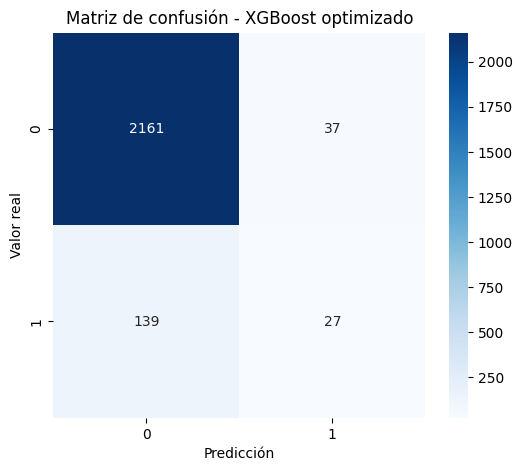

In [98]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de confusión - XGBoost optimizado")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

**Interpretación:** La matriz de confusión muestra que el modelo clasifica correctamente la gran mayoría de los casos pertenecientes a la clase 0, con 2161 verdaderos negativos y únicamente 37 falsos positivos.

Sin embargo, el rendimiento sobre la clase positiva es considerablemente menor. De los 166 casos positivos reales, el modelo identifica correctamente 27, mientras que 139 son clasificados erróneamente como clase 0. Esto explica el bajo `recall` obtenido para la clase 1 (0.16).

Estos resultados ponen de manifiesto el efecto del fuerte desbalance existente en la variable objetivo. Aunque el modelo alcanza un `accuracy` global de 0.93, esta métrica está fuertemente influenciada por la clase mayoritaria. Por este motivo, el `Balanced Accuracy` de 0.5729 proporciona una visión más representativa del rendimiento del modelo sobre ambas clases.

### 4.5 Conclusión de la parte obligatoria

A lo largo de la práctica se aplicaron diferentes técnicas de selección de características con el objetivo de identificar conjuntos de variables sencillos y con capacidad predictiva sobre `SeriousDlqin2yrs`.

Tras comparar seis conjuntos de features con tres modelos de clasificación mediante validación cruzada, la combinación `Visual + Varianza` con `XGBoost` obtuvo el mayor `Balanced Accuracy` medio. Posteriormente, la optimización mediante `GridSearchCV` mejoró este resultado de aproximadamente **0.5992** a **0.6036** en validación cruzada.

Al evaluar el modelo optimizado sobre el conjunto de test se obtuvo un `Balanced Accuracy` de **0.5729**. La matriz de confusión y el `classification_report` muestran que el modelo identifica correctamente la mayoría de los casos de la clase 0, pero presenta mayores dificultades para detectar la clase minoritaria, alcanzando un `recall` de **0.16** para la clase positiva.

Por tanto, aunque la selección de features y la optimización permiten construir un modelo relativamente sencillo, los resultados finales evidencian que el fuerte desbalance de clases continúa siendo una de las principales limitaciones del problema.

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

Como análisis adicional, aplicamos `PCA` (*Principal Component Analysis*) sobre el conjunto de entrenamiento para estudiar si es posible reducir la dimensionalidad de los datos conservando una parte elevada de la información original.

Dado que PCA es sensible a la escala de las variables, comenzamos estandarizando las features antes de calcular los componentes principales.

### E.1 Estandarización de las variables

In [99]:
scaler_pca = StandardScaler()

X_pca_scaled = scaler_pca.fit_transform(X_modelo)

print("Dimensiones antes de PCA:", X_modelo.shape)
print("Dimensiones después del escalado:", X_pca_scaled.shape)

Dimensiones antes de PCA: (9452, 10)
Dimensiones después del escalado: (9452, 10)


### E.2 Aplicación inicial de PCA

Aplicamos PCA utilizando inicialmente todos los componentes disponibles. De esta forma podremos analizar la proporción de varianza explicada por cada componente y determinar posteriormente cuántos componentes sería conveniente conservar.

In [100]:
pca = PCA()

X_pca = pca.fit_transform(X_pca_scaled)

varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

resultados_pca = pd.DataFrame({
    "Componente": [f"PC{i}" for i in range(1, len(varianza_explicada) + 1)],
    "Varianza explicada": varianza_explicada,
    "Varianza acumulada": varianza_acumulada
})

resultados_pca.round(4)

,Componente,Varianza explicada,Varianza acumulada
0,PC1,0.2000,0.2000
1,PC2,0.1494,0.3494
2,PC3,0.1196,0.4690
3,PC4,0.1024,0.5714
4,PC5,0.0916,0.6629
5,PC6,0.0795,0.7424
6,PC7,0.0712,0.8136
7,PC8,0.0697,0.8833
8,PC9,0.0624,0.9457
9,PC10,0.0543,1.0000


### E.3 Análisis de la varianza explicada acumulada

Representamos la varianza explicada acumulada por los componentes principales para visualizar cuántos componentes son necesarios para conservar una proporción elevada de la información original.

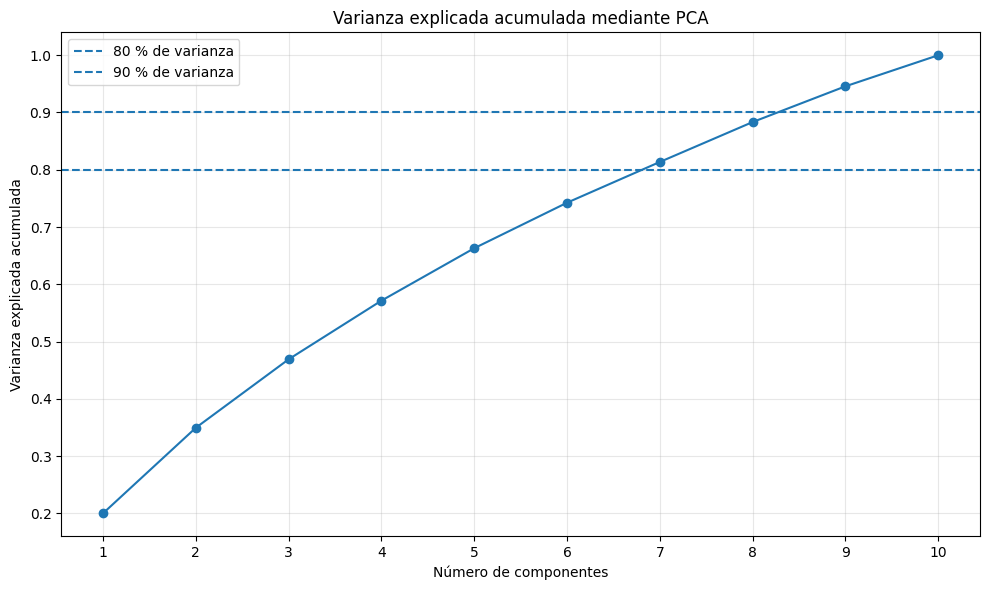

In [101]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada,
    marker="o"
)

plt.axhline(
    y=0.80,
    linestyle="--",
    label="80 % de varianza"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90 % de varianza"
)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada mediante PCA")

plt.xticks(range(1, len(varianza_acumulada) + 1))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:** La varianza explicada se encuentra distribuida entre varios componentes principales. Los primeros cinco componentes acumulan aproximadamente el 66.29 % de la varianza, mientras que con siete componentes se alcanza el 81.36 %.

Para superar el 90 % sería necesario conservar nueve de los diez componentes originales, por lo que la reducción de dimensionalidad sería mínima. Por este motivo, utilizaremos como referencia un umbral del 80 %, que permite reducir el conjunto de 10 variables originales a 7 componentes conservando aproximadamente el 81.36 % de la varianza.

### E.4 Reducción de dimensionalidad conservando el 80 % de la varianza

Aplicamos nuevamente PCA indicando que queremos conservar al menos el 80 % de la varianza total. De esta forma, el algoritmo determina automáticamente el número mínimo de componentes necesarios para alcanzar dicho umbral.

In [102]:
pca_80 = PCA(n_components=0.80)

X_train_pca_80 = pca_80.fit_transform(X_pca_scaled)

print("Número de variables originales:", X_modelo.shape[1])
print("Número de componentes seleccionados:", pca_80.n_components_)
print(
    "Varianza explicada acumulada:",
    round(pca_80.explained_variance_ratio_.sum(), 4)
)

Número de variables originales: 10
Número de componentes seleccionados: 7
Varianza explicada acumulada: 0.8136


### E.5 Transformación del conjunto de test

Aplicamos al conjunto de test el mismo escalado y la misma transformación PCA ajustados previamente sobre el conjunto de entrenamiento. De esta forma evitamos utilizar información del conjunto de test durante el proceso de preparación de los datos.

In [103]:
# Escalamos Test utilizando el scaler ajustado con Train
X_test_pca_scaled = scaler_pca.transform(X_test_modelo)

# Aplicamos el PCA ajustado con Train
X_test_pca_80 = pca_80.transform(X_test_pca_scaled)

print("Dimensiones Train con PCA:", X_train_pca_80.shape)
print("Dimensiones Test con PCA:", X_test_pca_80.shape)

Dimensiones Train con PCA: (9452, 7)
Dimensiones Test con PCA: (2364, 7)


### E.6 Entrenamiento de XGBoost con los componentes PCA

Entrenamos un modelo `XGBoost` utilizando los siete componentes principales obtenidos mediante PCA. Para facilitar la comparación con el modelo basado en selección de features, utilizamos la misma configuración de hiperparámetros obtenida previamente mediante `GridSearchCV`.

In [104]:
xgb_pca = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42
)

xgb_pca.fit(X_train_pca_80, y_train_final)

y_pred_pca = xgb_pca.predict(X_test_pca_80)

balanced_acc_pca = balanced_accuracy_score(
    y_test,
    y_pred_pca
)

print(
    "Balanced Accuracy en Test con PCA:",
    round(balanced_acc_pca, 4)
)

Balanced Accuracy en Test con PCA: 0.5933


### E.7 Comparación visual: selección de features vs PCA

Comparamos el `Balanced Accuracy` obtenido en el conjunto de test por el modelo XGBoost utilizando las features seleccionadas y utilizando los componentes principales obtenidos mediante PCA.

In [106]:
comparacion_final = pd.DataFrame({
    "Método": [
        "Selección de features",
        "PCA"
    ],
    "Balanced Accuracy": [
        balanced_acc_test,
        balanced_acc_pca
    ]
})

comparacion_final

,Método,Balanced Accuracy
0,Selección de features,0.572909
1,PCA,0.593310


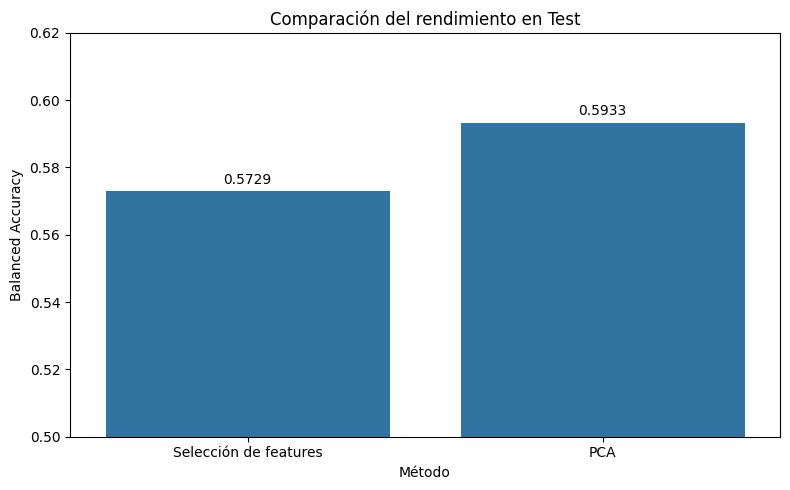

In [107]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=comparacion_final,
    x="Método",
    y="Balanced Accuracy"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

plt.title("Comparación del rendimiento en Test")
plt.xlabel("Método")
plt.ylabel("Balanced Accuracy")
plt.ylim(0.5, 0.62)

plt.tight_layout()
plt.show()

### E.8 Evaluación del modelo con PCA

Además del `Balanced Accuracy`, analizamos las métricas de clasificación para comprobar el comportamiento del modelo sobre cada una de las clases, especialmente sobre la clase positiva, que presenta una representación considerablemente menor en el dataset.

In [105]:
print(
    classification_report(
        y_test,
        y_pred_pca
    )
)

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      2198
           1       0.46      0.20      0.28       166

    accuracy                           0.93      2364
   macro avg       0.70      0.59      0.62      2364
weighted avg       0.91      0.93      0.91      2364



**Interpretación:** El modelo XGBoost entrenado con los componentes obtenidos mediante PCA alcanza un `Balanced Accuracy` de **0.5933** en el conjunto de test, superior al **0.5729** obtenido con la selección de features.

Además, el `recall` de la clase positiva aumenta de **0.16** con la selección de features a **0.20** utilizando PCA, mientras que el rendimiento sobre la clase mayoritaria se mantiene elevado, con un `recall` de **0.98**.

Por tanto, PCA proporciona una mejora tanto en el rendimiento equilibrado global como en la capacidad para detectar observaciones de la clase minoritaria. Sin embargo, el `recall` de la clase positiva continúa siendo bajo, lo que indica que el desbalance de clases sigue afectando de forma importante al rendimiento del modelo.

### E.9 Conclusión del análisis mediante PCA

La aplicación de PCA permitió reducir las **10 variables originales a 7 componentes principales**, conservando aproximadamente el **81.36 % de la varianza** del conjunto de datos.

Utilizando estos componentes para entrenar el mismo tipo de modelo seleccionado en la parte obligatoria, `XGBoost`, se obtuvo un `Balanced Accuracy` de **0.5933** en test, frente al **0.5729** obtenido mediante selección de features.

Además, el `recall` de la clase positiva aumentó de **0.16 a 0.20**, aunque continúa siendo bajo debido al fuerte desbalance existente en la variable objetivo.

En este caso, PCA permitió reducir la dimensionalidad y obtuvo un rendimiento superior al conjunto de features seleccionado. Como contrapartida, los componentes principales pierden la interpretabilidad directa de las variables originales.